<a href="https://colab.research.google.com/github/rirfan3689/CSCI323-Spam-Detection/blob/main/notebooks/12_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
import numpy as np
from scipy.sparse import load_npz
import json

uploaded = files.upload()  # Upload 8 files:
                           # Processed data (4 files):
                           # X_train.npz, X_test.npz, y_train.npy, y_test.npy
                           # Baseline results (4 files):
                           # nb_results.json, lr_results.json
                           # svm_results.json, rf_results.json

X_train = load_npz('X_train.npz')
X_test = load_npz('X_test.npz')
y_train = np.load('y_train.npy', allow_pickle=True)
y_test = np.load('y_test.npy', allow_pickle=True)

print("Data loaded successfully!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Saving X_test.npz to X_test.npz
Saving X_train.npz to X_train.npz
Saving y_test.npy to y_test.npy
Saving y_train.npy to y_train.npy
Saving nb_results.json to nb_results.json
Saving lr_results.json to lr_results.json
Saving svm_results.json to svm_results.json
Saving rf_results.json to rf_results.json
Data loaded successfully!
X_train shape: (4135, 5000)
X_test shape: (1034, 5000)


In [3]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, \
                            recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
import json

print("Libraries loaded!")

Libraries loaded!


In [4]:
baseline_files = {
    'Naive Bayes': 'nb_results.json',
    'Logistic Regression': 'lr_results.json',
    'SVM': 'svm_results.json',
    'Random Forest': 'rf_results.json'
}

baseline = {}
for name, filename in baseline_files.items():
    with open(filename) as f:
        data = json.load(f)
        baseline[name] = {
            'accuracy': data['accuracy'],
            'precision': data['precision'],
            'recall': data['recall'],
            'f1': data['f1']
        }

print("=== Baseline Results Loaded ===")
for name, results in baseline.items():
    print(f"{name}: F1={results['f1']:.4f}, Recall={results['recall']:.4f}")

=== Baseline Results Loaded ===
Naive Bayes: F1=0.8559, Recall=0.7481
Logistic Regression: F1=0.7798, Recall=0.6489
SVM: F1=0.8988, Recall=0.8473
Random Forest: F1=0.8833, Recall=0.8092


In [5]:
param_grids = {
    'Naive Bayes': {
        'model': MultinomialNB(),
        'params': {
            'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.01, 0.1, 1.0, 10.0],
            'class_weight': [None, 'balanced']
        }
    },
    'SVM': {
        'model': SVC(kernel='linear', random_state=42),
        'params': {
            'C': [0.01, 0.1, 1.0, 10.0]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5]
        }
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Parameter grids defined!")

Parameter grids defined!


In [6]:
print("=== Hyperparameter Tuning — UCI SMS Dataset ===\n")

tuned_results = {}

for name, config in param_grids.items():
    print(f"Tuning {name}...")
    grid_search = GridSearchCV(
        config['model'],
        config['params'],
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    y_pred = grid_search.best_estimator_.predict(X_test)
    tuned_results[name] = {
        'best_params': grid_search.best_params_,
        'best_cv_f1': round(grid_search.best_score_, 4),
        'accuracy': round(accuracy_score(y_test, y_pred), 4),
        'precision': round(precision_score(y_test, y_pred, pos_label='spam'), 4),
        'recall': round(recall_score(y_test, y_pred, pos_label='spam'), 4),
        'f1': round(f1_score(y_test, y_pred, pos_label='spam'), 4)
    }

    print(f"  Best params: {grid_search.best_params_}")
    print(f"  Best CV F1:  {tuned_results[name]['best_cv_f1']}")
    print(f"  Accuracy:    {tuned_results[name]['accuracy']}")
    print(f"  Precision:   {tuned_results[name]['precision']}")
    print(f"  Recall:      {tuned_results[name]['recall']}")
    print(f"  F1:          {tuned_results[name]['f1']}\n")

=== Hyperparameter Tuning — UCI SMS Dataset ===

Tuning Naive Bayes...
  Best params: {'alpha': 0.1}
  Best CV F1:  0.9409
  Accuracy:    0.9681
  Precision:   0.8769
  Recall:      0.8702
  F1:          0.8736

Tuning Logistic Regression...
  Best params: {'C': 10.0, 'class_weight': 'balanced'}
  Best CV F1:  0.9437
  Accuracy:    0.9749
  Precision:   0.8947
  Recall:      0.9084
  F1:          0.9015

Tuning SVM...
  Best params: {'C': 1.0}
  Best CV F1:  0.9408
  Accuracy:    0.9758
  Precision:   0.9569
  Recall:      0.8473
  F1:          0.8988

Tuning Random Forest...
  Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
  Best CV F1:  0.9275
  Accuracy:    0.9758
  Precision:   0.9818
  Recall:      0.8244
  F1:          0.8963



In [7]:
print("=== Logistic Regression Investigation — Low Recall ===\n")

lr_default = LogisticRegression(max_iter=1000, random_state=42)
lr_balanced = LogisticRegression(max_iter=1000, random_state=42,
                                  class_weight='balanced')

lr_default.fit(X_train, y_train)
lr_balanced.fit(X_train, y_train)

y_pred_default = lr_default.predict(X_test)
y_pred_balanced = lr_balanced.predict(X_test)

print("Default LR:")
print(f"  Precision: {precision_score(y_test, y_pred_default, pos_label='spam'):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_default, pos_label='spam'):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred_default, pos_label='spam'):.4f}")

print("\nBalanced LR (class_weight='balanced'):")
print(f"  Precision: {precision_score(y_test, y_pred_balanced, pos_label='spam'):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_balanced, pos_label='spam'):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred_balanced, pos_label='spam'):.4f}")

recall_improvement = recall_score(y_test, y_pred_balanced, pos_label='spam') - \
                     recall_score(y_test, y_pred_default, pos_label='spam')
f1_improvement = f1_score(y_test, y_pred_balanced, pos_label='spam') - \
                 f1_score(y_test, y_pred_default, pos_label='spam')

print(f"\nRecall improved by: {recall_improvement:.4f} (+{recall_improvement*100:.2f}%)")
print(f"F1 improved by:     {f1_improvement:.4f} (+{f1_improvement*100:.2f}%)")
print("\nConclusion: Class imbalance was the key factor in LR's low recall")

=== Logistic Regression Investigation — Low Recall ===

Default LR:
  Precision: 0.9770
  Recall:    0.6489
  F1:        0.7798

Balanced LR (class_weight='balanced'):
  Precision: 0.8741
  Recall:    0.9008
  F1:        0.8872

Recall improved by: 0.2519 (+25.19%)
F1 improved by:     0.1074 (+10.74%)

Conclusion: Class imbalance was the key factor in LR's low recall


In [8]:
print("=== Baseline vs Tuned Comparison ===\n")
print(f"{'Model':<25} {'Metric':<12} {'Baseline':<12} {'Tuned':<12} {'Change':<10}")
print("-" * 75)

for name in baseline.keys():
    for metric in ['accuracy', 'precision', 'recall', 'f1']:
        b_val = baseline[name][metric]
        t_val = tuned_results[name][metric]
        change = t_val - b_val
        change_str = f"+{change:.4f}" if change >= 0 else f"{change:.4f}"
        print(f"{name:<25} {metric:<12} {b_val:.4f}{'':>4} {t_val:.4f}{'':>4} {change_str}")
    print()

=== Baseline vs Tuned Comparison ===

Model                     Metric       Baseline     Tuned        Change    
---------------------------------------------------------------------------
Naive Bayes               accuracy     0.9681     0.9681     +0.0000
Naive Bayes               precision    1.0000     0.8769     -0.1231
Naive Bayes               recall       0.7481     0.8702     +0.1221
Naive Bayes               f1           0.8559     0.8736     +0.0177

Logistic Regression       accuracy     0.9536     0.9749     +0.0213
Logistic Regression       precision    0.9770     0.8947     -0.0823
Logistic Regression       recall       0.6489     0.9084     +0.2595
Logistic Regression       f1           0.7798     0.9015     +0.1217

SVM                       accuracy     0.9758     0.9758     -0.0000
SVM                       precision    0.9569     0.9569     +0.0000
SVM                       recall       0.8473     0.8473     -0.0000
SVM                       f1           0.8988    

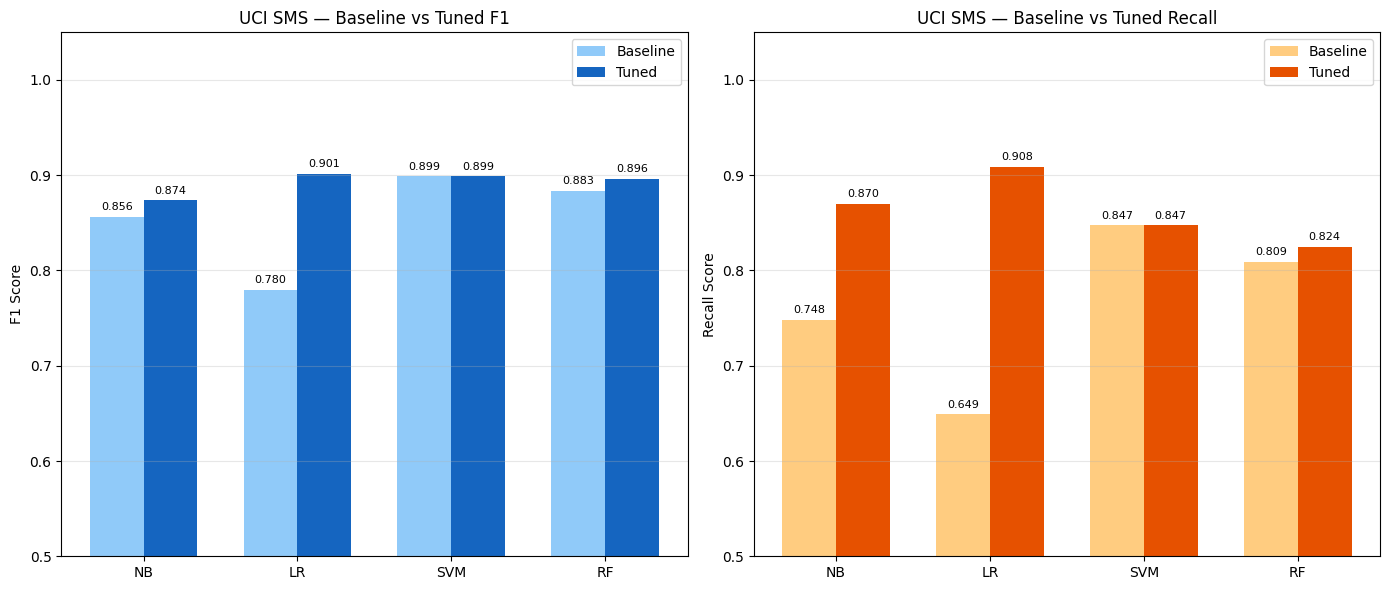

In [9]:
model_names = list(baseline.keys())
short_names = ['NB', 'LR', 'SVM', 'RF']
x = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# F1 comparison
baseline_f1 = [baseline[m]['f1'] for m in model_names]
tuned_f1 = [tuned_results[m]['f1'] for m in model_names]

bars1 = axes[0].bar(x - width/2, baseline_f1, width,
                    label='Baseline', color='#90CAF9')
bars2 = axes[0].bar(x + width/2, tuned_f1, width,
                    label='Tuned', color='#1565C0')
axes[0].set_title('UCI SMS — Baseline vs Tuned F1')
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names)
axes[0].set_ylim(0.5, 1.05)
axes[0].set_ylabel('F1 Score')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

# Recall comparison
baseline_recall = [baseline[m]['recall'] for m in model_names]
tuned_recall = [tuned_results[m]['recall'] for m in model_names]

bars3 = axes[1].bar(x - width/2, baseline_recall, width,
                    label='Baseline', color='#FFCC80')
bars4 = axes[1].bar(x + width/2, tuned_recall, width,
                    label='Tuned', color='#E65100')
axes[1].set_title('UCI SMS — Baseline vs Tuned Recall')
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names)
axes[1].set_ylim(0.5, 1.05)
axes[1].set_ylabel('Recall Score')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('tuning_comparison.png')
plt.show()

In [10]:
with open('tuning_results.json', 'w') as f:
    json.dump(tuned_results, f)

print("Tuning results saved!")
print("\nBest Parameters Summary:")
for name, results in tuned_results.items():
    print(f"  {name}: {results['best_params']}")

Tuning results saved!

Best Parameters Summary:
  Naive Bayes: {'alpha': 0.1}
  Logistic Regression: {'C': 10.0, 'class_weight': 'balanced'}
  SVM: {'C': 1.0}
  Random Forest: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
